# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "loan_status"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 17,500 / 列数: 10
目的変数列: loan_status


,id,loan_amnt,term,interest_rate,grade,employment_length,purpose,credit_score,application_type,loan_status
0,0,1256.710800,5 years,10.603779,B1,5 years,debt_consolidation,680.431766,Individual,0
1,1,569.559607,3 years,17.305565,C5,3 years,house,713.063128,Individual,0
2,2,1118.838050,3 years,14.041342,C3,2 years,debt_consolidation,696.137378,Individual,1
3,3,610.721728,3 years,13.048348,C2,5 years,medical,656.373090,Individual,0
4,4,1180.026840,3 years,11.384862,B3,10 years,debt_consolidation,657.211233,Individual,0
5,5,1172.219819,3 years,11.397183,B3,5 years,debt_consolidation,712.157342,Joint App,0
6,6,2433.646304,3 years,10.101810,B3,10 years,debt_consolidation,713.201971,Individual,0
7,7,1021.960300,5 years,18.093028,D4,4 years,debt_consolidation,658.299475,Individual,0
8,8,1200.741420,5 years,11.090507,B1,7 years,debt_consolidation,771.964087,Individual,0
9,9,1731.132899,5 years,17.732408,D3,4 years,debt_consolidation,657.732889,Individual,1


## 1. データ概要


In [3]:
try:
    import pandas as pd
    import numpy as np
    from pathlib import Path

    print('【データ概要】')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n【列一覧】')
    print(df.columns.tolist())

    print('\n【先頭5行】')
    print(df.head())

    print('\n【データ型】')
    print(df.dtypes)

    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\nメモリ使用量(MB): {mem_mb:.2f}')

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    object_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    print(f'\n数値列数: {len(numeric_cols)}')
    print(f'カテゴリ列数: {len(object_cols)}')

    if 'id' in df.columns:
        print(f"\nid列の一意数: {df['id'].nunique()} / {len(df)}")
        print(f"id重複件数: {df['id'].duplicated().sum()}")

    print('\n【数値列の要約統計】')
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().T)

    print('\n【カテゴリ列の要約】')
    if len(object_cols) > 0:
        cat_summary = pd.DataFrame({
            'unique': df[object_cols].nunique(dropna=False),
            'top': df[object_cols].astype(str).mode(dropna=False).iloc[0],
            'freq': [df[c].astype(str).value_counts(dropna=False).iloc[0] for c in object_cols]
        })
        print(cat_summary.sort_values('unique'))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


【データ概要】


行数: 17500
列数: 10

【列一覧】
['id', 'loan_amnt', 'term', 'interest_rate', 'grade', 'employment_length', 'purpose', 'credit_score', 'application_type', 'loan_status']

【先頭5行】
   id    loan_amnt     term  interest_rate grade employment_length  \
0   0  1256.710800  5 years      10.603779    B1           5 years   
1   1   569.559607  3 years      17.305565    C5           3 years   
2   2  1118.838050  3 years      14.041342    C3           2 years   
3   3   610.721728  3 years      13.048348    C2           5 years   
4   4  1180.026840  3 years      11.384862    B3          10 years   

              purpose  credit_score application_type  loan_status  
0  debt_consolidation    680.431766       Individual            0  
1               house    713.063128       Individual            0  
2  debt_consolidation    696.137378       Individual            1  
3             medical    656.373090       Individual            0  
4  debt_consolidation    657.211233       Individual            0  



C:\Users\hikeshita\AppData\Local\Temp\ipykernel_64420\1352183015.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


## 2. 欠損分析


【欠損値集計】
                   欠損数  欠損率(%)
id                   0     0.0
loan_amnt            0     0.0
term                 0     0.0
interest_rate        0     0.0
grade                0     0.0
employment_length    0     0.0
purpose              0     0.0
credit_score         0     0.0
application_type     0     0.0
loan_status          0     0.0


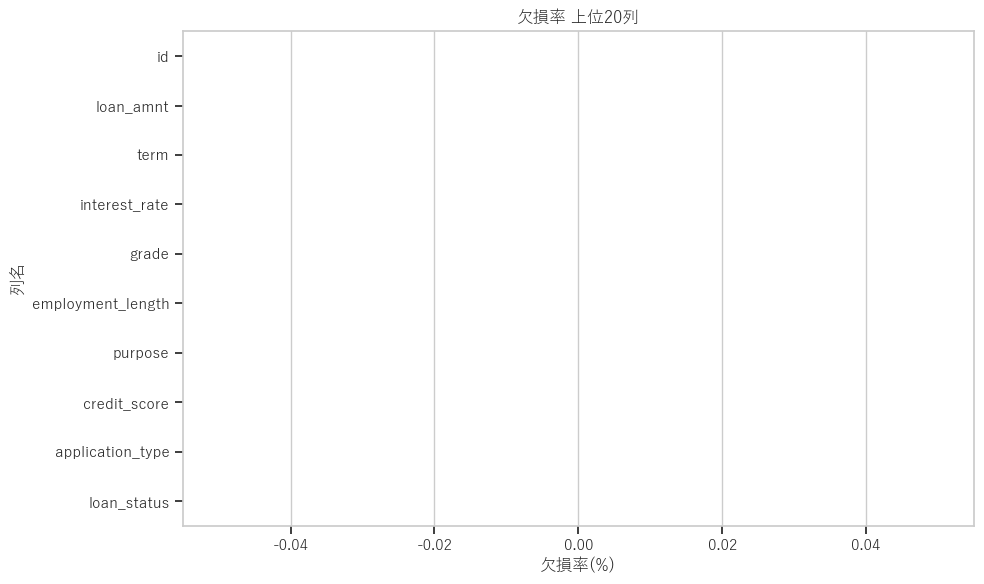

In [4]:
try:
    from pathlib import Path

    missing_count = df.isnull().sum().sort_values(ascending=False)
    missing_rate = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_count, '欠損率(%)': missing_rate})
    missing_df_nonzero = missing_df[missing_df['欠損数'] > 0]

    print('【欠損値集計】')
    print(missing_df)

    plt.figure(figsize=(10, 6))
    plot_df = missing_df.head(20).sort_values('欠損率(%)', ascending=True)
    sns.barplot(x=plot_df['欠損率(%)'], y=plot_df.index, color='tomato')
    plt.title('欠損率 上位20列')
    plt.xlabel('欠損率(%)')
    plt.ylabel('列名')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    if not missing_df_nonzero.empty:
        print('\n【欠損のある列】')
        print(missing_df_nonzero)
        if missing_df_nonzero.shape[0] <= 30:
            plt.figure(figsize=(min(1.2 * missing_df_nonzero.shape[0] + 4, 18), 4))
            sns.heatmap(df[missing_df_nonzero.index].isnull(), cbar=True, yticklabels=False, cmap='viridis')
            plt.title('欠損パターン')
            plt.xlabel('列名')
            plt.tight_layout()
            plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


【数値列一覧】
['id', 'loan_amnt', 'interest_rate', 'credit_score', 'loan_status']

【数値列要約統計】
                 count         mean         std         min          25%  \
loan_amnt      17500.0  1582.993986  830.193264  400.972831  1067.690423   
interest_rate  17500.0    14.457565    5.074348    5.315124    10.906715   
credit_score   17500.0   683.206178   30.166656  649.316663   659.023544   

                       50%          75%          max      skew      kurt  
loan_amnt      1189.121646  2249.821992  3815.251133  0.922633 -0.130939  
interest_rate    13.813722    18.057546    27.970416  0.424071 -0.569885  
credit_score    678.063411   699.448349   802.764452  1.526567  2.364087  


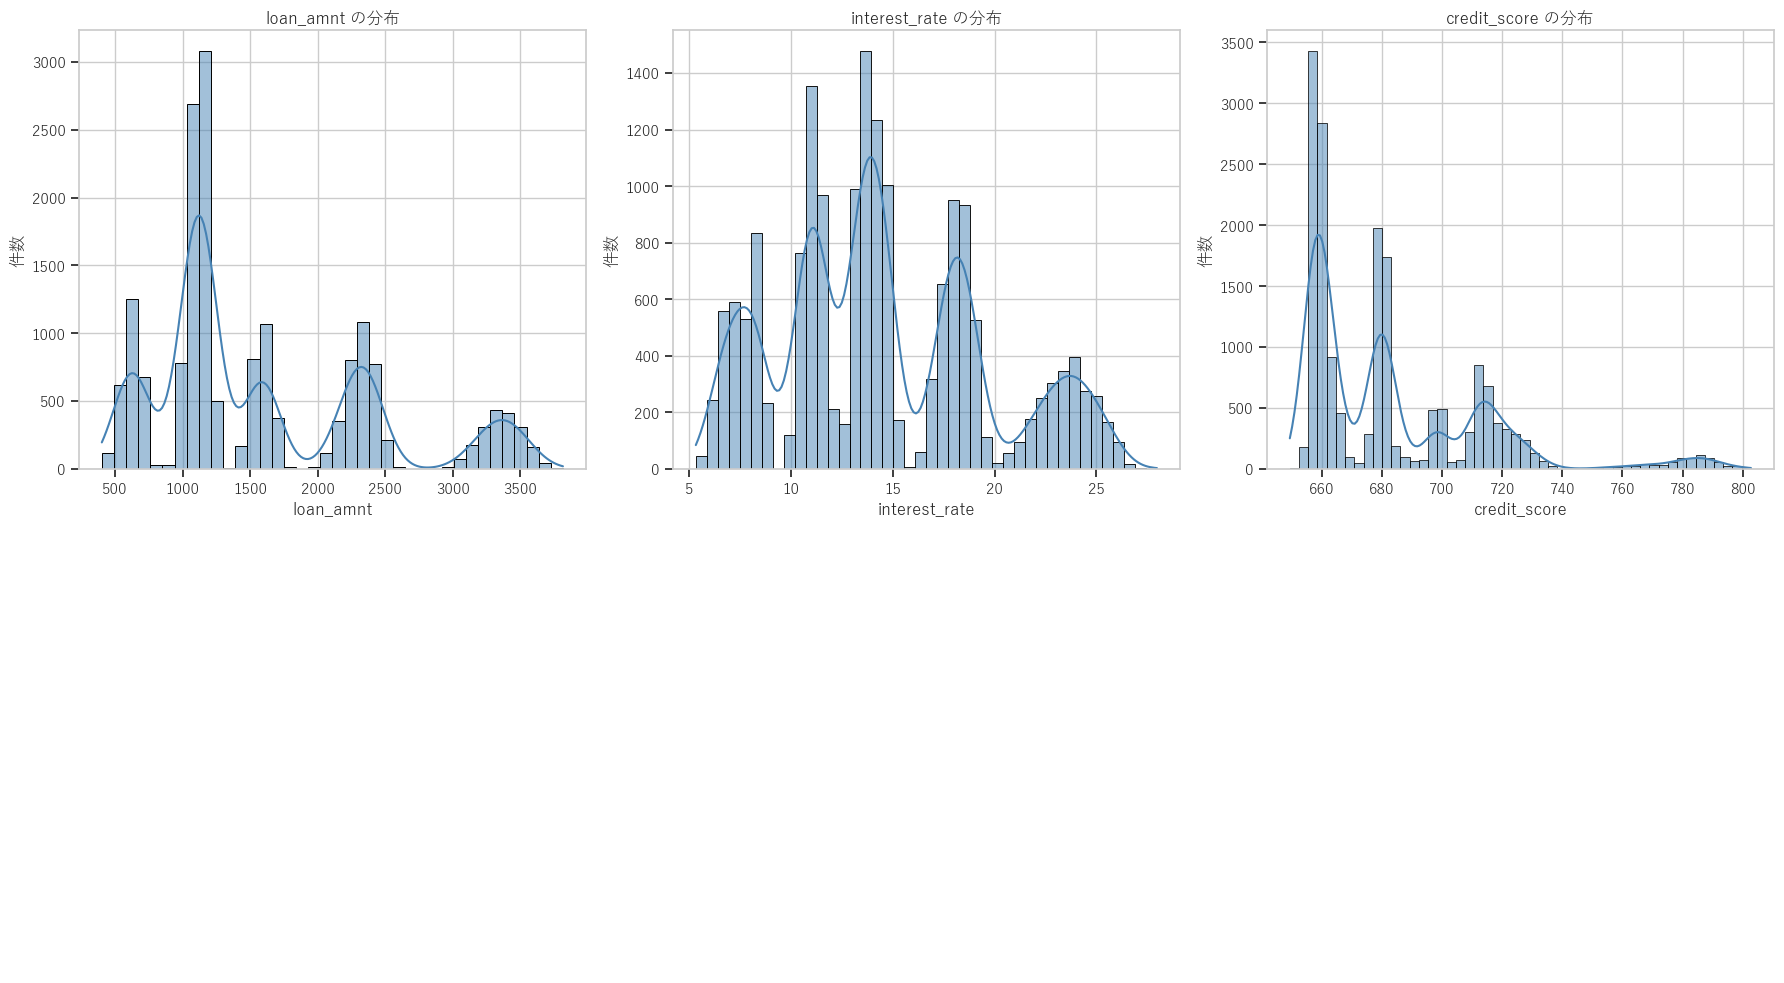

In [5]:
try:
    from pathlib import Path

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_numeric_cols = [c for c in numeric_cols if c != target_col]
    if 'id' in feature_numeric_cols:
        feature_numeric_cols.remove('id')

    print('【数値列一覧】')
    print(numeric_cols)

    if len(feature_numeric_cols) > 0:
        desc = df[feature_numeric_cols].describe().T
        desc['skew'] = df[feature_numeric_cols].skew(numeric_only=True)
        desc['kurt'] = df[feature_numeric_cols].kurt(numeric_only=True)
        print('\n【数値列要約統計】')
        print(desc)

        top_cols = feature_numeric_cols[:6]
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        for i, col in enumerate(top_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
            axes[i].set_title(f'{col} の分布')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('件数')
        for j in range(len(top_cols), 6):
            axes[j].axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        for i, col in enumerate(top_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='orange')
            axes[i].set_title(f'{col} の箱ひげ図')
            axes[i].set_xlabel(col)
        for j in range(len(top_cols), 6):
            axes[j].axis('off')
        plt.tight_layout()
        plt.close()

        if target_col in df.columns:
            for col in top_cols[:3]:
                plt.figure(figsize=(8, 5))
                sns.boxplot(data=df, x=target_col, y=col)
                plt.title(f'{col} と目的変数の関係')
                plt.xlabel('目的変数')
                plt.ylabel(col)
                plt.tight_layout()
                plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "loan_status"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_64420\4193844454.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


【カテゴリ列一覧】
['term', 'grade', 'employment_length', 'purpose', 'application_type']

【カテゴリ列要約】
                  列名  ユニーク数                 最頻値  最頻値件数
0               term      2             3 years  13259
4   application_type      2          Individual  15774
3            purpose      9  debt_consolidation  10996
2  employment_length     11            10 years   5234
1              grade     27                  C4   1769


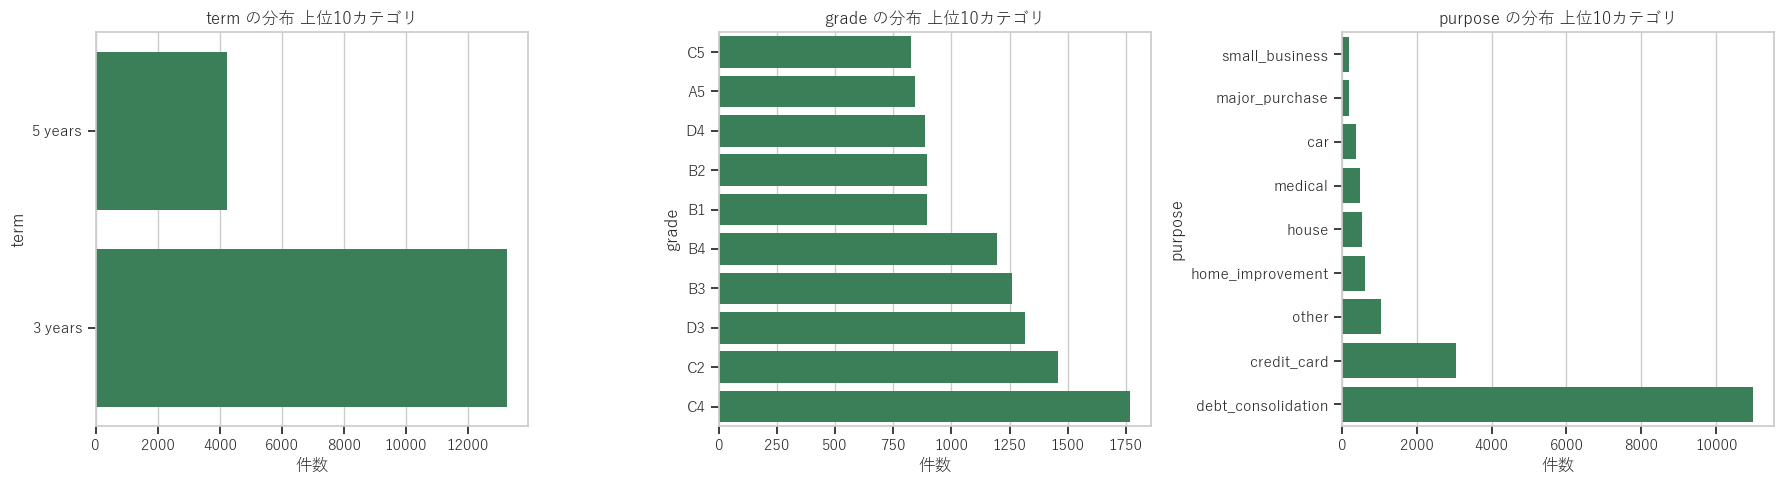


【term と目的変数のクロス集計（行比率）】
loan_status         0         1
term                           
3 years      0.807904  0.192096
5 years      0.714218  0.285782

【grade と目的変数のクロス集計（行比率）】
loan_status         0         1
grade                          
A1           0.960100  0.039900
A2           0.966725  0.033275
A3           0.787819  0.212181
A4           0.952744  0.047256
A5           0.945498  0.054502
B1           0.769231  0.230769
B2           0.800223  0.199777
B3           0.843775  0.156225
B4           0.828881  0.171119
B5           0.678886  0.321114
C1           0.831746  0.168254
C2           0.796982  0.203018
C3           0.885154  0.114846
C4           0.764839  0.235161
C5           0.787183  0.212817
D1           0.787313  0.212687
D2           0.760757  0.239243
D3           0.618361  0.381639
D4           0.586907  0.413093
D5           0.738574  0.261426

【purpose と目的変数のクロス集計（行比率）】
loan_status                0         1
purpose                               
car        

In [6]:
try:
    from pathlib import Path
    import re

    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != target_col]

    print('【カテゴリ列一覧】')
    print(cat_cols)

    summary_rows = []
    for col in cat_cols:
        vc = df[col].value_counts(dropna=False)
        summary_rows.append({
            '列名': col,
            'ユニーク数': df[col].nunique(dropna=False),
            '最頻値': vc.index[0] if len(vc) > 0 else np.nan,
            '最頻値件数': vc.iloc[0] if len(vc) > 0 else np.nan
        })
    if summary_rows:
        print('\n【カテゴリ列要約】')
        print(pd.DataFrame(summary_rows).sort_values('ユニーク数'))

    preferred = [c for c in ['term', 'grade', 'purpose'] if c in cat_cols]
    plot_cols = preferred[:3]
    if len(plot_cols) < 3:
        for c in cat_cols:
            if c not in plot_cols:
                plot_cols.append(c)
            if len(plot_cols) == 3:
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if len(plot_cols) == 1:
        axes = [axes]
    for i in range(3):
        ax = axes[i]
        if i < len(plot_cols):
            col = plot_cols[i]
            plot_df = df[col].astype(str).value_counts(dropna=False).head(10).sort_values(ascending=True)
            sns.barplot(x=plot_df.values, y=plot_df.index, ax=ax, color='seagreen')
            ax.set_title(f'{col} の分布 上位10カテゴリ')
            ax.set_xlabel('件数')
            ax.set_ylabel(col)
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    if target_col in df.columns:
        for col in plot_cols:
            if col in df.columns:
                ct = pd.crosstab(df[col], df[target_col], normalize='index')
                print(f'\n【{col} と目的変数のクロス集計（行比率）】')
                print(ct.head(20))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


【目的変数の基本集計】
loan_status
0    13741
1     3759
Name: count, dtype: int64

【目的変数の割合】
loan_status
0    78.52
1    21.48
Name: proportion, dtype: float64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_64420\4055946583.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=order, palette='Set2')


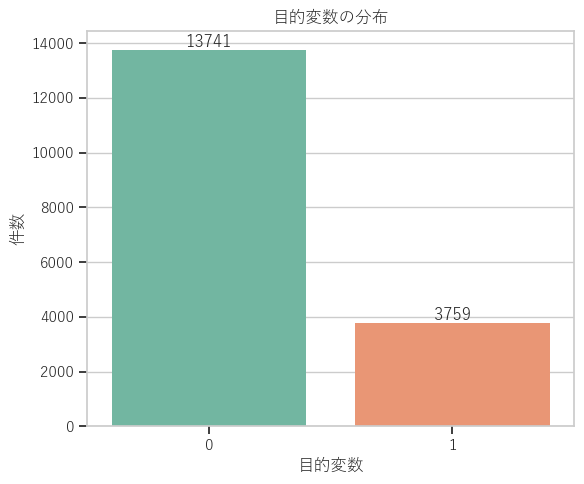


平均値: 0.2148
標準偏差: 0.4107


In [7]:
try:
    from pathlib import Path

    print('【目的変数の基本集計】')
    print(df[target_col].value_counts(dropna=False).sort_index())
    print('\n【目的変数の割合】')
    print((df[target_col].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))

    plt.figure(figsize=(6, 5))
    order = sorted(df[target_col].dropna().unique().tolist()) if df[target_col].dropna().nunique() > 0 else None
    ax = sns.countplot(data=df, x=target_col, order=order, palette='Set2')
    plt.title('目的変数の分布')
    plt.xlabel('目的変数')
    plt.ylabel('件数')
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2, h), ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    if pd.api.types.is_numeric_dtype(df[target_col]):
        print(f'\n平均値: {df[target_col].mean():.4f}')
        print(f'標準偏差: {df[target_col].std():.4f}')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


【相関行列】
               loan_amnt  interest_rate  credit_score  loan_status
loan_amnt       1.000000       0.175675      0.159816     0.015965
interest_rate   0.175675       1.000000     -0.343825     0.257194
credit_score    0.159816      -0.343825      1.000000    -0.179251
loan_status     0.015965       0.257194     -0.179251     1.000000


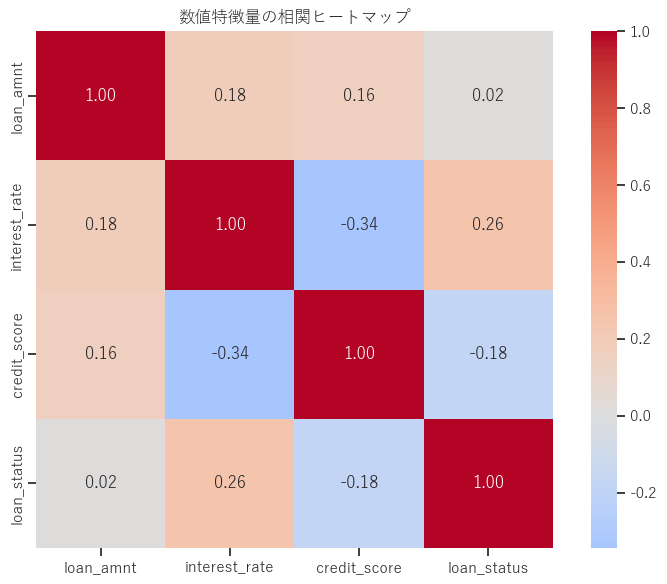


【目的変数との相関】
interest_rate    0.257194
credit_score    -0.179251
loan_amnt        0.015965
Name: loan_status, dtype: float64


In [8]:
try:
    from pathlib import Path

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    use_cols = [c for c in numeric_cols if c != 'id']

    if len(use_cols) >= 2:
        corr = df[use_cols].corr(numeric_only=True)
        print('【相関行列】')
        print(corr)

        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
        plt.title('数値特徴量の相関ヒートマップ')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        if target_col in corr.columns:
            target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
            print('\n【目的変数との相関】')
            print(target_corr)

            if len(target_corr) > 0:
                plt.figure(figsize=(8, max(4, 0.6 * len(target_corr))))
                plot_s = target_corr.sort_values()
                colors = ['crimson' if v < 0 else 'royalblue' for v in plot_s.values]
                plt.barh(plot_s.index, plot_s.values, color=colors)
                plt.title('目的変数との相関')
                plt.xlabel('相関係数')
                plt.ylabel('特徴量')
                plt.tight_layout()
                plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


【日付列の確認】
候補列: []
採用列: []


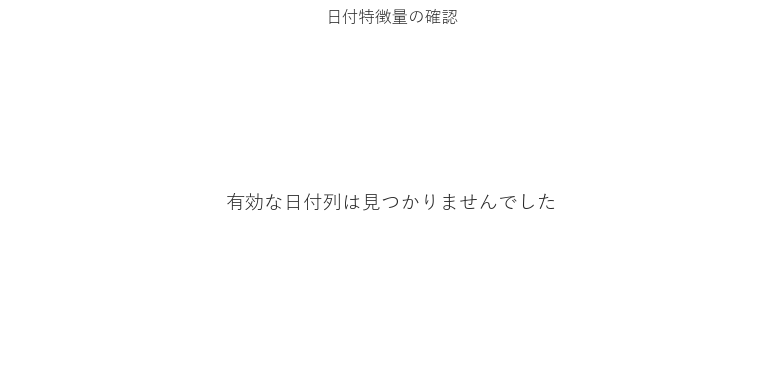

In [9]:
try:
    from pathlib import Path
    import re

    print('【日付列の確認】')

    def is_pure_day_number_column(s):
        s2 = s.dropna()
        if len(s2) == 0:
            return False
        num = pd.to_numeric(s2, errors='coerce')
        if num.isna().any():
            return False
        vals = num.astype(float)
        return vals.between(1, 31).all()

    candidate_cols = []
    if date_col_hint not in [None, 'None', ''] and date_col_hint in df.columns:
        candidate_cols.append(date_col_hint)

    for col in df.columns:
        if col in candidate_cols:
            continue
        lower = str(col).lower()
        if any(k in lower for k in ['date', 'time', 'day', 'month', 'year']):
            candidate_cols.append(col)

    valid_date_cols = []
    for col in candidate_cols:
        if is_pure_day_number_column(df[col]):
            continue
        parsed = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)
        if parsed.notna().mean() >= 0.8:
            valid_date_cols.append(col)

    print('候補列:', candidate_cols)
    print('採用列:', valid_date_cols)

    if valid_date_cols:
        col = valid_date_cols[0]
        tmp = pd.DataFrame({'_date': pd.to_datetime(df[col], errors='coerce'), '_target': df[target_col] if target_col in df.columns else np.nan})
        tmp = tmp.dropna(subset=['_date']).sort_values('_date')
        freq = 'M'
        trend = tmp.set_index('_date').resample(freq).size().rename('件数').to_frame()
        if target_col in df.columns and pd.api.types.is_numeric_dtype(df[target_col]):
            trend['目的変数平均'] = tmp.set_index('_date')['_target'].resample(freq).mean()

        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax1.plot(trend.index, trend['件数'], color='tab:blue', marker='o')
        ax1.set_title(f'{col} の時系列推移')
        ax1.set_xlabel('日付')
        ax1.set_ylabel('件数', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        if '目的変数平均' in trend.columns:
            ax2 = ax1.twinx()
            ax2.plot(trend.index, trend['目的変数平均'], color='tab:red', marker='s')
            ax2.set_ylabel('目的変数平均', color='tab:red')
            ax2.tick_params(axis='y', labelcolor='tab:red')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, '有効な日付列は見つかりませんでした', ha='center', va='center', fontsize=14)
        plt.title('日付特徴量の確認')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    print('【EDAサマリー】')
    print(f'データ形状: {df.shape[0]}行 × {df.shape[1]}列')
    print(f'数値列数: {len(numeric_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')
    print(f'欠損値総数: {int(df.isnull().sum().sum())}')

    if target_col in df.columns:
        print('\n【目的変数サマリー】')
        print(df[target_col].value_counts(dropna=False).sort_index())
        print((df[target_col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2).rename('割合(%)'))

    if len(numeric_cols) > 0:
        non_id_numeric = [c for c in numeric_cols if c not in ['id', target_col]]
        if non_id_numeric:
            print('\n【数値特徴量の代表統計】')
            stat_df = df[non_id_numeric].agg(['mean', 'std', 'min', 'max']).T.sort_index()
            print(stat_df)

    if len(cat_cols) > 0:
        print('\n【カテゴリ特徴量のユニーク数】')
        print(df[cat_cols].nunique(dropna=False).sort_values())

    if target_col in df.columns and pd.api.types.is_numeric_dtype(df[target_col]) and len(numeric_cols) >= 2:
        corr = df[[c for c in numeric_cols if c != 'id']].corr(numeric_only=True)
        if target_col in corr.columns:
            print('\n【目的変数との相関 上位】')
            print(corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False))

    print('\n【確認ポイント】')
    print('- id は識別子の可能性が高いため特徴量利用時は注意')
    print('- term、grade、employment_length は順序性を持つ可能性あり')
    print('- purpose、application_type はカテゴリ変数としてエンコード候補')
    print('- loan_amnt、interest_rate、credit_score は目的変数との関係を重点確認')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


【EDAサマリー】
データ形状: 17500行 × 10列
数値列数: 5
カテゴリ列数: 5
欠損値総数: 0

【目的変数サマリー】
loan_status
0    13741
1     3759
Name: count, dtype: int64
loan_status
0    78.52
1    21.48
Name: 割合(%), dtype: float64

【数値特徴量の代表統計】
                      mean         std         min          max
credit_score    683.206178   30.166656  649.316663   802.764452
interest_rate    14.457565    5.074348    5.315124    27.970416
loan_amnt      1582.993986  830.193264  400.972831  3815.251133

【カテゴリ特徴量のユニーク数】
term                  2
application_type      2
purpose               9
employment_length    11
grade                27
dtype: int64

【目的変数との相関 上位】
interest_rate    0.257194
credit_score    -0.179251
loan_amnt        0.015965
Name: loan_status, dtype: float64

【確認ポイント】
- id は識別子の可能性が高いため特徴量利用時は注意
- term、grade、employment_length は順序性を持つ可能性あり
- purpose、application_type はカテゴリ変数としてエンコード候補
- loan_amnt、interest_rate、credit_score は目的変数との関係を重点確認


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_64420\2025018763.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
